# Prediksi Harga Mobil Bekas

Notebook ini membangun model machine learning untuk memprediksi harga mobil bekas berdasarkan atribut kendaraan. Permasalahan ini diselesaikan sebagai kasus regresi karena target yang diprediksi adalah nilai numerik, yaitu `price`.

## 1. Setup dan Load Dataset

Bagian ini digunakan untuk menyiapkan library yang dibutuhkan dan memuat dataset dari Kaggle. Dataset dimuat dalam bentuk dataframe agar dapat dianalisis dan diproses menggunakan pandas.

### 1.1 Instalasi Package
 menginstal package `kagglehub` agar dataset dari Kaggle dapat dimuat langsung ke notebook.

In [ ]:
!pip install -q kagglehub[pandas-datasets]

### 1.2 Import Library
 mengimpor library yang digunakan untuk manipulasi data, visualisasi, preprocessing, modeling, dan evaluasi. Contohnya `pandas` untuk dataframe, `seaborn` dan `matplotlib` untuk visualisasi, serta `scikit-learn` untuk machine learning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1.3 Memuat Dataset

memuat file `autos.csv` dari dataset Kaggle ke dalam dataframe `df`. Dataframe inilah yang akan digunakan untuk proses analisis, preprocessing, dan modeling.

In [ ]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "thedevastator/uncovering-factors-that-affect-used-car-prices",
    "autos.csv",
)

100%|██████████| 18.2M/18.2M [00:00<00:00, 37.5MB/s]

Extracting zip of autos.csv...


#### Interpretasi Output

Jika dataset berhasil dimuat tanpa error, dataframe `df` sudah tersedia dan siap digunakan untuk proses eksplorasi data.

## 2. Data Understanding

Tahap ini digunakan untuk memahami struktur dataset, jumlah data, tipe data, missing value, statistik numerik, dan kemungkinan masalah seperti duplikasi, nilai tidak valid, serta outlier. Informasi ini menjadi dasar sebelum melakukan data preparation.

### 2.1 Pemeriksaan Awal Dataset

Beberapa pemeriksaan awal dilakukan untuk memahami data, seperti melihat contoh baris, jumlah data, tipe data, dan jumlah missing value. Tahap ini membantu menentukan langkah preprocessing yang diperlukan.

#### 2.1.1 Melihat Contoh Data

Kode `df.head()` digunakan untuk menampilkan beberapa baris pertama dataset. Tujuannya adalah memahami bentuk data, nama kolom, dan contoh nilai pada setiap fitur.

In [ ]:
df.head()

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


#### Interpretasi Output

Output `df.head()` menampilkan contoh lima baris pertama. Dari output ini, kita dapat melihat struktur kolom, contoh nilai, dan gambaran awal isi dataset.

#### 2.1.2 Melihat Ukuran Dataset

Kode `df.shape` digunakan untuk mengetahui jumlah baris dan kolom pada dataset. Ini berguna untuk memastikan dataset memenuhi syarat jumlah sampel minimum dan memahami skala data.

In [ ]:
df.shape

(371528, 21)

#### Interpretasi Output

Output `df.shape` menunjukkan ukuran dataset awal. Dataset memiliki jumlah sampel yang besar sehingga memenuhi syarat minimum data untuk proyek machine learning.

#### 2.1.3 Melihat Informasi Tipe Data

Kode `df.info()` digunakan untuk melihat tipe data setiap kolom, jumlah data non null, dan struktur dataframe. Informasi ini penting untuk menentukan kolom mana yang perlu dikonversi, seperti kolom tanggal.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

#### Interpretasi Output

Output `df.info()` menunjukkan tipe data setiap kolom. Kolom tanggal masih perlu dikonversi menjadi datetime, sedangkan kolom kategorikal dan numerik akan diproses dengan teknik yang berbeda.

#### 2.1.4 Mengecek Missing Value Awal

Kode `df.isnull().sum()` digunakan untuk menghitung jumlah nilai kosong pada setiap kolom. Hasil ini membantu menentukan kolom mana yang perlu ditangani dengan imputasi atau strategi lain.

In [ ]:
df.isnull().sum()

,0
index,0
dateCrawled,0
name,0
seller,0
offerType,0
price,0
abtest,0
vehicleType,37869
yearOfRegistration,0
gearbox,20209


#### Interpretasi Output

Output missing value awal menunjukkan kolom mana saja yang memiliki nilai kosong sebelum cleaning. Kolom seperti `vehicleType`, `gearbox`, `model`, `fuelType`, dan `notRepairedDamage` memiliki missing value yang perlu ditangani.

### 2.2 Kolom dengan Nilai Hilang (NaN)

### 2.3 Statistik Deskriptif, Duplikasi, dan Harga 0

Statistik deskriptif digunakan untuk melihat nilai minimum, maksimum, rata-rata, dan sebaran data numerik. Tahap ini juga digunakan untuk mengecek duplikasi dan mengidentifikasi data dengan `price = 0` sebelum data tersebut dibersihkan.

#### Interpretasi Output

Output statistik deskriptif memperlihatkan adanya nilai ekstrem, seperti `price` yang sangat tinggi, `yearOfRegistration` yang tidak masuk akal, dan `powerPS` yang terlalu besar. Informasi ini digunakan untuk menentukan strategi cleaning.

#### 2.3.1 Melihat Statistik Deskriptif

Kode `df.describe().T` digunakan untuk melihat ringkasan statistik kolom numerik, seperti nilai minimum, maksimum, rata rata, median, dan kuartil. Dari sini dapat terlihat indikasi outlier seperti harga sangat besar, tahun tidak masuk akal, atau `powerPS` ekstrem.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,371528.0,185763.500000,1.072510e+05,0.0,92881.75,185763.5,278645.25,3.715270e+05
price,371528.0,17295.141865,3.587954e+06,0.0,1150.00,2950.0,7200.00,2.147484e+09
yearOfRegistration,371528.0,2004.577997,9.286660e+01,1000.0,1999.00,2003.0,2008.00,9.999000e+03
powerPS,371528.0,115.549477,1.921396e+02,0.0,70.00,105.0,150.00,2.000000e+04
kilometer,371528.0,125618.688228,4.011234e+04,5000.0,125000.00,150000.0,150000.00,1.500000e+05
monthOfRegistration,371528.0,5.734445,3.712412e+00,0.0,3.00,6.0,9.00,1.200000e+01
nrOfPictures,371528.0,0.000000,0.000000e+00,0.0,0.00,0.0,0.00,0.000000e+00
postalCode,371528.0,50820.667640,2.579908e+04,1067.0,30459.00,49610.0,71546.00,9.999800e+04


#### Interpretasi Output

Output duplikasi menunjukkan apakah ada baris yang sama persis. Jika hasilnya 0, berarti tidak ada duplikasi penuh yang perlu dihapus.

#### 2.3.2 Mengecek Duplikasi Data

Kode ini menghitung jumlah baris duplikat. Jika terdapat duplikasi, data perlu dipertimbangkan untuk dibersihkan agar model tidak belajar dari data yang berulang.

In [ ]:
df.duplicated().sum()

np.int64(0)

#### Interpretasi Output

Output menampilkan baris-baris yang memiliki `price = 0`. Data seperti ini dianggap tidak valid karena harga mobil bekas seharusnya tidak bernilai 0.

#### 2.3.3 Melihat Data dengan Harga 0

Kode ini menampilkan baris yang memiliki `price = 0`. Tujuannya adalah memastikan bahwa nilai tersebut memang ada dan perlu dibersihkan karena tidak merepresentasikan harga mobil yang valid.

In [ ]:
df.loc[(df['price']==0)]

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
7,7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,...,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
40,40,2016-03-26 22:06:17,Suche_Opel_corsa_a_zu_verschenken,privat,Angebot,0,test,NaN,1990,NaN,...,corsa,150000,1,benzin,opel,NaN,2016-03-26 00:00:00,0,56412,2016-03-27 17:43:34
115,115,2016-03-19 18:40:12,Golf_IV_1.4_16V,privat,Angebot,0,test,NaN,2017,manuell,...,golf,5000,12,benzin,volkswagen,NaN,2016-03-19 00:00:00,0,21698,2016-04-01 08:47:05
119,119,2016-03-20 18:53:27,Polo_6n_Karosse_zu_verschenken,privat,Angebot,0,test,kleinwagen,1999,NaN,...,NaN,5000,0,benzin,volkswagen,NaN,2016-03-20 00:00:00,0,37520,2016-04-07 02:45:22
157,157,2016-03-11 18:55:53,Opel_meriva_1.6_16_v_lpg__z16xe_no_OPC,privat,Angebot,0,test,bus,2004,manuell,...,meriva,150000,10,lpg,opel,ja,2016-03-11 00:00:00,0,27432,2016-03-12 23:47:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371356,371356,2016-03-09 15:56:30,Verkaufen_einen_Opel_corsa_b_worlcup_cool,privat,Angebot,0,control,NaN,2000,manuell,...,corsa,150000,0,NaN,opel,ja,2016-03-09 00:00:00,0,23758,2016-03-30 11:16:08
371392,371392,2016-03-20 14:55:07,Ford_Fiesta_1.3___60PS___Bj_2002___Klima___Servo,privat,Angebot,0,test,kleinwagen,2002,manuell,...,fiesta,150000,3,benzin,ford,NaN,2016-03-20 00:00:00,0,33659,2016-04-06 18:45:23
371402,371402,2016-03-24 13:48:05,Suzuki_Swift_zu_verkaufen,privat,Angebot,0,control,kleinwagen,1999,manuell,...,swift,150000,3,benzin,suzuki,NaN,2016-03-24 00:00:00,0,42329,2016-04-07 05:17:24
371431,371431,2016-03-10 22:55:50,Seat_Arosa,privat,Angebot,0,control,kleinwagen,1999,manuell,...,arosa,150000,7,benzin,seat,ja,2016-03-10 00:00:00,0,22559,2016-03-12 23:46:32


#### Interpretasi Output

Output menunjukkan jumlah data setelah baris dengan `price = 0` dihapus. Jumlah baris berkurang karena data harga yang tidak valid tidak digunakan dalam modeling.

## 3. Data Preparation

Tahap ini membersihkan data agar siap digunakan untuk modeling. Beberapa proses yang dilakukan meliputi menghapus harga tidak valid, mengubah kolom tanggal, menangani nilai 0 yang sebenarnya merepresentasikan missing value, menangani outlier, membuat fitur `car_age`, menghapus kolom yang tidak relevan, serta melakukan imputasi setelah train-test split untuk mencegah data leakage.

### 3.1 Menghapus Harga Tidak Valid

Data dengan `price = 0` dihapus karena harga mobil tidak mungkin bernilai 0. Nilai ini dianggap sebagai data tidak valid atau placeholder, sehingga tidak digunakan dalam modeling.

#### Interpretasi Output

Cell konversi datetime biasanya tidak menampilkan output. Jika tidak muncul error, berarti kolom tanggal berhasil dikonversi dan dapat digunakan untuk mengambil informasi tahun.

In [ ]:
df = df.loc[(df[["price"]]!=0).all(axis=1)]

df.shape

(360750, 21)

### 3.2 Mengubah Kolom Tanggal Menjadi Datetime

Kolom `dateCrawled`, `dateCreated`, dan `lastSeen` diubah menjadi tipe `datetime` menggunakan `pd.to_datetime()`. Perubahan ini diperlukan agar informasi tanggal dapat diproses, misalnya untuk mengambil tahun dan membuat fitur baru seperti `car_age`.

#### Interpretasi Output

Output menampilkan rentang tanggal dari kolom `dateCrawled`, `dateCreated`, dan `lastSeen`. Rentang tanggal ini membantu memastikan bahwa data berasal dari periode waktu yang konsisten.

#### 3.2.1 Kode Konversi Datetime

 membuat daftar kolom tanggal, lalu mengubah setiap kolom menjadi tipe datetime menggunakan `pd.to_datetime()`. Parameter `errors="coerce"` digunakan agar nilai yang gagal dikonversi menjadi `NaT`, bukan membuat error.

In [ ]:
date_cols = [
    "dateCrawled",
    "dateCreated",
    "lastSeen",
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

#### Interpretasi Output

Output `max_year` menunjukkan tahun maksimum pada data crawling. Nilai ini digunakan sebagai batas atas agar `yearOfRegistration` tidak melebihi tahun pengambilan data.

#### 3.2.2 Melihat Rentang Tanggal

 menampilkan tanggal minimum dan maksimum dari setiap kolom tanggal. Tujuannya adalah memastikan hasil konversi datetime benar dan mengetahui rentang waktu dataset.

In [ ]:
for col in date_cols:
    print(col)
    print(df[col].min())
    print(df[col].max())

dateCrawled
2016-03-05 14:06:22
2016-04-07 14:36:58
dateCreated
2014-03-10 00:00:00
2016-04-07 00:00:00
lastSeen
2016-03-05 14:15:08
2016-04-07 14:58:51


#### Interpretasi Output

Output statistik `yearOfRegistration` menunjukkan nilai minimum dan maksimum yang tidak realistis. Hal ini menjadi alasan mengapa kolom tahun registrasi perlu difilter.

#### 3.2.3 Menentukan Tahun Maksimum Dataset

 mengambil tahun terbesar dari `dateCrawled`. Nilai ini digunakan sebagai batas atas untuk mengecek apakah `yearOfRegistration` masih masuk akal.

In [ ]:
max_year = int(df["dateCrawled"].dt.year.max())
print(max_year)

2016


#### Interpretasi Output

Boxplot `yearOfRegistration` menunjukkan adanya nilai ekstrem pada tahun registrasi. Visual ini mendukung keputusan untuk melakukan filtering tahun dengan batas yang lebih masuk akal.

### 3.3 Mengubah Nilai 0 Menjadi NaN

Nilai 0 pada `powerPS` dan `monthOfRegistration` dianggap tidak valid. Tenaga mobil 0 tidak masuk akal, dan bulan registrasi valid hanya 1 sampai 12. Karena itu, nilai 0 diubah menjadi NaN agar dapat ditangani melalui imputasi.

In [ ]:
df["powerPS"] = df["powerPS"].replace(0, np.nan)
df["monthOfRegistration"] = df["monthOfRegistration"].replace(0, np.nan)

#### Interpretasi Output

Cell ini mengubah nilai 0 menjadi NaN dan biasanya tidak menampilkan output. Perubahan tersebut bisa dilihat pada cell berikutnya saat jumlah missing value dicek ulang.

#### 3.3.1 Mengecek Missing Value Setelah Konversi Nilai 0

Setelah `powerPS` dan `monthOfRegistration` bernilai 0 diubah menjadi NaN, kode ini mengecek ulang jumlah missing value. Hasilnya menunjukkan tambahan NaN yang akan ditangani pada tahap imputasi.

In [ ]:
df.isnull().sum()

,0
index,0
dateCrawled,0
name,0
seller,0
offerType,0
price,0
abtest,0
vehicleType,34127
yearOfRegistration,0
gearbox,17729


#### Interpretasi Output

Output menunjukkan jumlah missing value setelah nilai 0 pada `powerPS` dan `monthOfRegistration` diubah menjadi NaN. Jumlah NaN bertambah karena nilai 0 yang tidak valid kini dianggap sebagai missing value.

#### 3.3.2 Menampilkan Kolom yang Masih Memiliki NaN

Kode ini menyaring hasil missing value agar hanya kolom dengan jumlah NaN lebih dari 0 yang ditampilkan. Tujuannya agar fokus pada kolom yang memang perlu ditangani.

In [ ]:
nan_cols_detailed = df.isnull().sum()
nan_cols_detailed = nan_cols_detailed[nan_cols_detailed > 0]
display(nan_cols_detailed.sort_values(ascending=False))

,0
notRepairedDamage,66770
powerPS,36951
vehicleType,34127
monthOfRegistration,33202
fuelType,29948
model,18300
gearbox,17729


#### Interpretasi Output

Output menampilkan hanya kolom yang masih memiliki NaN. Kolom dengan jumlah NaN terbesar perlu diperhatikan, tetapi tidak langsung dihapus karena akan ditangani dengan imputasi.

### 3.4 Mengambil Kolom Numerik

Kolom numerik dipisahkan untuk memudahkan proses visualisasi distribusi dan outlier. Tahap ini membantu fokus pada fitur numerik `price`, `yearOfRegistration`, `powerPS`, `kilometer`, dan `monthOfRegistration`.

In [ ]:
numerical_cols = df.select_dtypes(include=["number"]).columns
numerical_cols.tolist()

['index',
 'price',
 'yearOfRegistration',
 'powerPS',
 'kilometer',
 'monthOfRegistration',
 'nrOfPictures',
 'postalCode']

#### Interpretasi Output

Output menampilkan daftar kolom numerik yang akan dianalisis lebih lanjut. Kolom ini digunakan untuk visualisasi boxplot dan histogram.

### 3.5 Visualisasi Distribusi dan Outlier Numerik

Boxplot digunakan untuk melihat outlier pada kolom numerik, sedangkan histogram digunakan untuk melihat bentuk distribusi data. Visualisasi ini membantu menentukan kolom mana yang perlu dibersihkan lebih lanjut.

#### 3.5.1 Boxplot Seluruh Kolom Numerik

Boxplot digunakan untuk melihat nilai ekstrem pada setiap kolom numerik. Visualisasi ini membantu mengidentifikasi kolom yang memiliki outlier, seperti `price`, `yearOfRegistration`, dan `powerPS`.

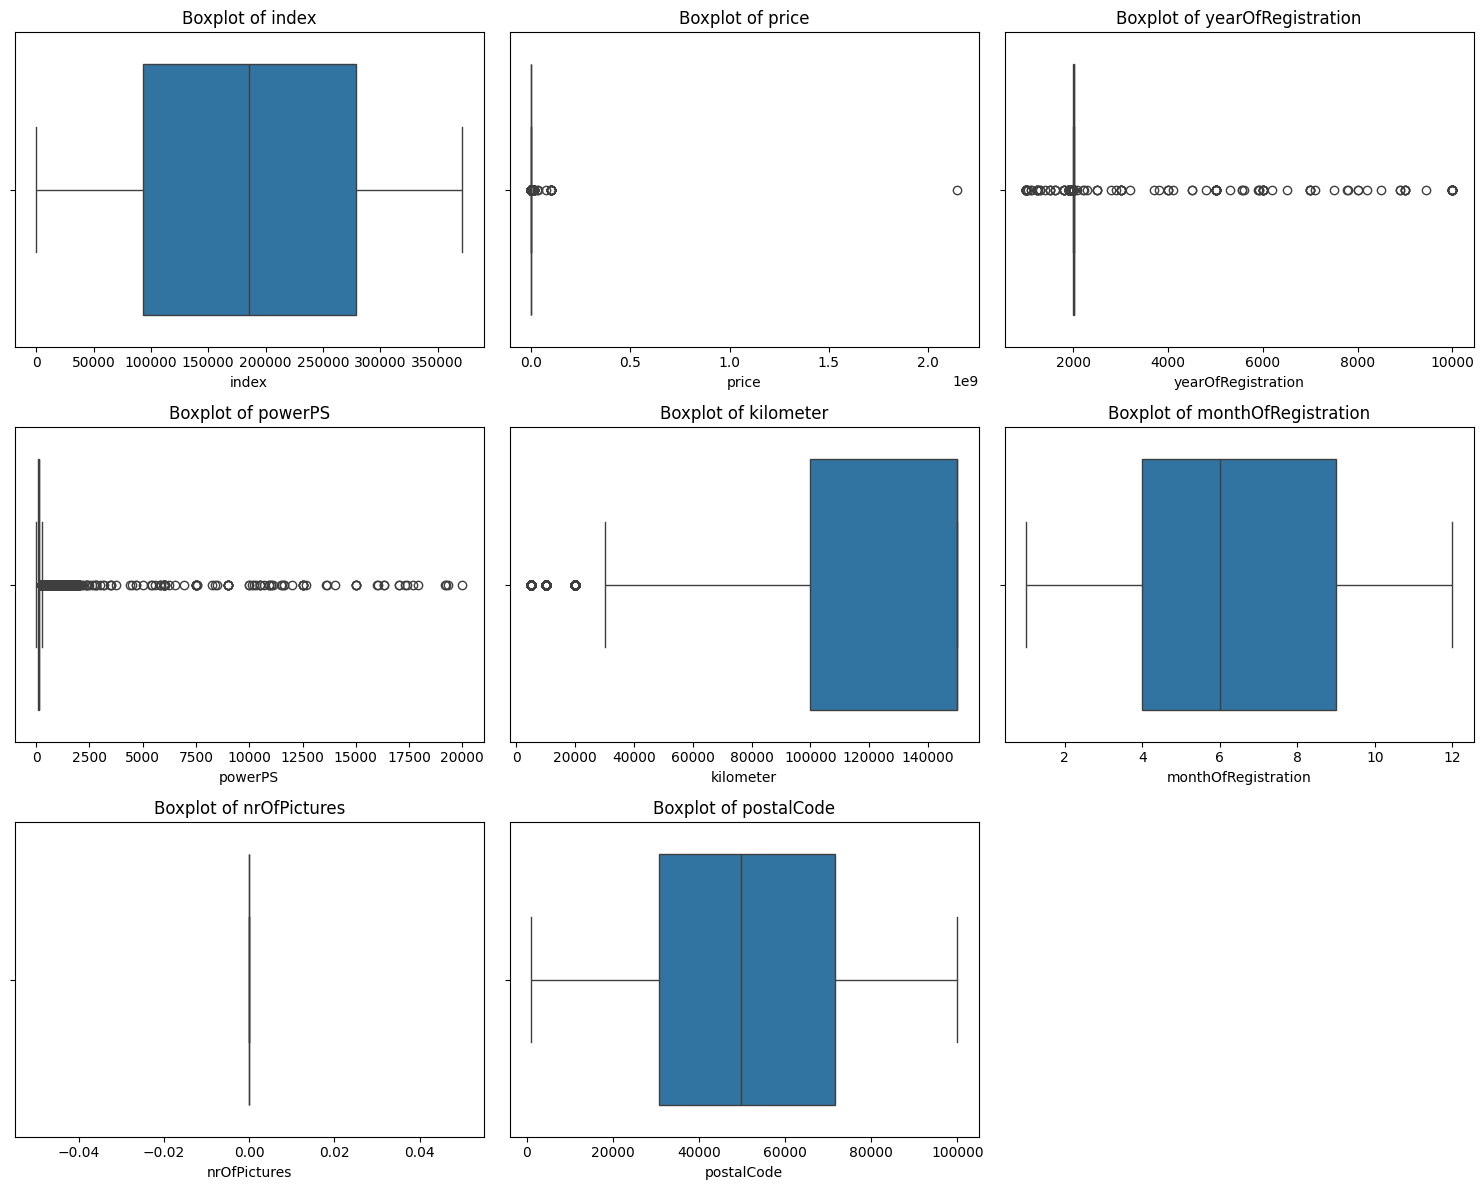

In [ ]:
num_plots = len(numerical_cols)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

#### Interpretasi Output

Boxplot seluruh kolom numerik membantu melihat kolom mana yang memiliki outlier ekstrem. Dari visualisasi ini, `powerPS`, `price`, dan `yearOfRegistration` terlihat perlu perhatian khusus.

#### 3.5.2 Histogram Kolom Numerik

Histogram digunakan untuk melihat bentuk distribusi nilai pada kolom numerik yang penting. Dari histogram, kita bisa melihat apakah data condong ke satu sisi, tersebar merata, atau memiliki konsentrasi nilai tertentu.

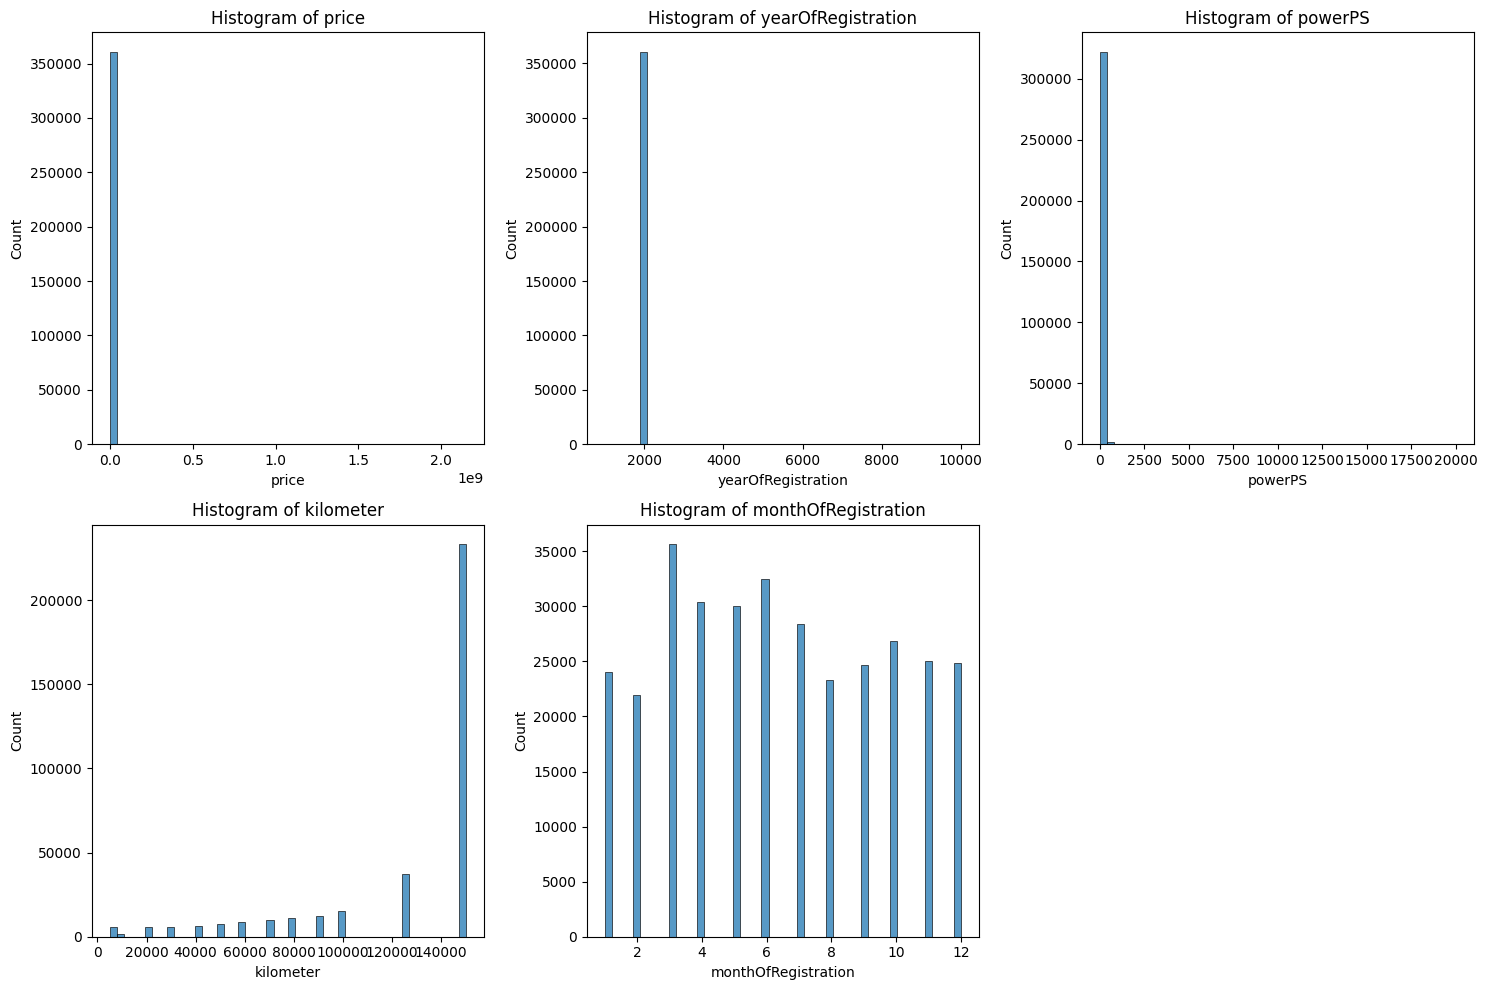

In [ ]:
plot_cols = [
    "price",
    "yearOfRegistration",
    "powerPS",
    "kilometer",
    "monthOfRegistration",
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(plot_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Histogram of {col}")

plt.tight_layout()
plt.show()

#### Interpretasi Output

Histogram menunjukkan pola distribusi masing-masing kolom numerik penting. Jika distribusi condong ke kanan, berarti sebagian besar data berada pada nilai rendah tetapi ada sebagian kecil nilai yang sangat tinggi.

### 3.6 Menangani Outlier `powerPS` dengan IQR

Boxplot menunjukkan bahwa `powerPS` memiliki outlier ekstrem. Metode IQR digunakan untuk menentukan batas bawah dan batas atas secara numerik. Nilai di luar batas tersebut dihapus, sedangkan NaN tetap dipertahankan untuk diimputasi setelah split data.

In [ ]:
Q1 = df["powerPS"].quantile(0.25)
Q3 = df["powerPS"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"powerPS IQR bounds: {lower:.2f} - {upper:.2f}")

df = df[df["powerPS"].between(lower, upper) | df["powerPS"].isna()]
df.shape

powerPS IQR bounds: -25.00 - 255.00


(348461, 21)

#### Interpretasi Output

Output menampilkan batas bawah dan batas atas IQR untuk `powerPS`, lalu jumlah data setelah outlier difilter. Nilai `powerPS` di luar batas dianggap terlalu ekstrem dan dihapus, sedangkan NaN tetap dipertahankan.

### 3.7 Feature Engineering: Membuat `car_age`

Fitur `car_age` dibuat dari selisih antara tahun iklan dibuat dan tahun registrasi kendaraan. Umur mobil penting karena kendaraan yang lebih tua umumnya memiliki harga lebih rendah.

In [ ]:
df["car_age"] = df["dateCreated"].dt.year - df["yearOfRegistration"]

#### Interpretasi Output

Cell ini membuat fitur baru `car_age`. Biasanya tidak ada output tabel, tetapi fitur baru tersebut akan digunakan pada proses filtering dan modeling.

### 3.8 Filtering Tahun Registrasi dan Harga

Data difilter agar tahun registrasi berada pada rentang yang masuk akal, umur mobil tidak negatif, dan harga tidak berada pada nilai ekstrem. Filtering ini membantu mengurangi pengaruh data tidak valid terhadap model.

In [ ]:
df = df[
    (df["yearOfRegistration"] >= 1990) &
    (df["yearOfRegistration"] <= max_year) &
    (df["car_age"] >= 0)
]

price_upper = df["price"].quantile(0.99)
df = df[(df["price"] >= 100) & (df["price"] <= price_upper)]

print(f"Shape after outlier filtering: {df.shape}")
df["car_age"].describe()

Shape after outlier filtering: (319772, 22)


,car_age
count,319772.000000
mean,12.564224
std,5.711740
min,0.000000
25%,8.000000
50%,13.000000
75%,17.000000
max,26.000000


#### Interpretasi Output

Output menunjukkan jumlah data setelah filtering outlier serta statistik `car_age`. Nilai maksimum `car_age` sebesar 26 berarti mobil tertua setelah cleaning berumur 26 tahun, bukan tahun 26.

### 3.9 Menghapus Kolom yang Tidak Digunakan

Beberapa kolom dihapus karena tidak relevan untuk modeling atau informasinya sudah diwakili oleh fitur lain. Contohnya, kolom tanggal dihapus setelah digunakan untuk membuat `car_age`, sedangkan `nrOfPictures` dihapus karena tidak informatif.

In [ ]:
drop_cols = [
    "index",
    "nrOfPictures",
    "seller",
    "offerType",
    "name",
    "dateCrawled",
    "dateCreated",
    "lastSeen",
    "abtest",
    "postalCode",
]

df = df.drop(columns=drop_cols)
print(f"Shape after dropping columns: {df.shape}")
df.head()

Shape after dropping columns: (319772, 12)


,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,car_age
0,480,NaN,1993,manuell,NaN,golf,150000,NaN,benzin,volkswagen,NaN,23
1,18300,coupe,2011,manuell,190.0,NaN,125000,5.0,diesel,audi,ja,5
2,9800,suv,2004,automatik,163.0,grand,125000,8.0,diesel,jeep,NaN,12
3,1500,kleinwagen,2001,manuell,75.0,golf,150000,6.0,benzin,volkswagen,nein,15
4,3600,kleinwagen,2008,manuell,69.0,fabia,90000,7.0,diesel,skoda,nein,8


#### Interpretasi Output

Output menampilkan bentuk dataset setelah kolom yang tidak relevan dihapus. Jumlah kolom menjadi lebih sedikit dan hanya fitur yang dianggap berguna untuk modeling yang dipertahankan.

### 3.10 Mengecek Missing Value Setelah Cleaning

Setelah proses cleaning dan penghapusan kolom selesai, missing value dicek kembali. Missing value yang masih tersisa tidak langsung dihapus, karena akan ditangani menggunakan imputasi setelah train-test split.

In [ ]:
nan_cols_final = df.isnull().sum()
nan_cols_final = nan_cols_final[nan_cols_final > 0]
display(nan_cols_final.sort_values(ascending=False))

,0
notRepairedDamage,55618
powerPS,30045
monthOfRegistration,26606
fuelType,21716
vehicleType,18184
gearbox,13611
model,13552


#### Interpretasi Output

Output menampilkan kolom yang masih memiliki NaN setelah cleaning final. NaN yang tersisa tidak langsung dihapus karena akan diisi menggunakan imputasi setelah data dibagi menjadi train dan test.

## 4. Modeling

Tahap modeling bertujuan membangun model machine learning yang mampu memprediksi `price` berdasarkan fitur kendaraan yang sudah diproses. Karena target berupa nilai numerik kontinu, pendekatan yang digunakan adalah regresi.

Pada tahap ini digunakan dua algoritma tree-based regression, yaitu Decision Tree Regressor dan Random Forest Regressor. Decision Tree merepresentasikan pendekatan pohon keputusan tunggal, sedangkan Random Forest merepresentasikan pendekatan ensemble yang menggabungkan banyak pohon keputusan.

Kedua model dilatih menggunakan data training yang sudah melalui proses imputasi dan encoding. Setelah itu, performanya dibandingkan menggunakan metrik evaluasi yang sama agar pemilihan model terbaik dilakukan secara objektif.

### 4.1 Memisahkan Fitur dan Target

Kolom `price` digunakan sebagai target karena nilai inilah yang ingin diprediksi. Kolom selain `price` digunakan sebagai fitur untuk membantu model mempelajari pola harga mobil bekas.

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

print(f"Jumlah data: {X.shape[0]:,}")
print(f"Jumlah fitur: {X.shape[1]}")

Jumlah data: 319,772
Jumlah fitur: 11


#### Interpretasi Output

Output menunjukkan jumlah data dan jumlah fitur setelah target `price` dipisahkan. Jumlah fitur inilah yang akan digunakan model untuk memprediksi harga mobil.

#### 4.1.1 Mengelompokkan Fitur Numerik dan Kategorikal

Kode ini memisahkan fitur berdasarkan tipe datanya. Pemisahan ini diperlukan karena fitur numerik dan kategorikal diproses dengan cara berbeda: numerik diimputasi dengan median, sedangkan kategorikal diimputasi dengan modus dan di-encoding.

In [ ]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Kolom numerik:")
print(num_cols)

print("\nKolom kategorikal:")
print(cat_cols)

Kolom numerik:
['yearOfRegistration', 'powerPS', 'kilometer', 'monthOfRegistration', 'car_age']

Kolom kategorikal:
['vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage']


#### Interpretasi Output

Output menampilkan daftar fitur numerik dan kategorikal. Daftar ini digunakan untuk menentukan perlakuan preprocessing yang berbeda antara kolom numerik dan kolom kategorikal.

### 4.2 Train-Test Split

Data dibagi menjadi data training dan testing sebelum imputasi dan encoding. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Jumlah data training: {X_train.shape[0]:,}")
print(f"Jumlah data testing: {X_test.shape[0]:,}")

Jumlah data training: 255,817
Jumlah data testing: 63,955


#### Interpretasi Output

Output menampilkan jumlah data training dan testing. Pembagian ini memastikan bahwa model dilatih pada data training dan dievaluasi pada data testing yang belum dilihat saat training.

#### 4.2.1 Mengecek NaN pada Data Training

Kode ini mengecek missing value pada `X_train` sebelum imputasi. Tujuannya adalah menunjukkan kolom mana saja yang perlu diisi nilainya sebelum data digunakan untuk melatih model.

In [ ]:
missing_before_imputation = X_train.isnull().sum()
missing_before_imputation = missing_before_imputation[missing_before_imputation > 0]

display(missing_before_imputation.sort_values(ascending=False))

,0
notRepairedDamage,44514
powerPS,24151
monthOfRegistration,21303
fuelType,17253
vehicleType,14546
gearbox,10932
model,10813


#### Interpretasi Output

Output ini menampilkan kolom pada data training yang masih memiliki missing value sebelum imputasi. Informasi ini membuktikan bahwa imputasi memang diperlukan sebelum model dilatih.

### 4.3 Imputasi Missing Value

Missing value diisi setelah data dibagi menjadi training dan testing. Kolom numerik diisi menggunakan median, sedangkan kolom kategorikal diisi menggunakan modus. Imputer di-fit hanya pada data training untuk mencegah data leakage.

In [ ]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test_imputed[num_cols] = num_imputer.transform(X_test[num_cols])

X_train_imputed[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test_imputed[cat_cols] = cat_imputer.transform(X_test[cat_cols])

missing_after_imputation = X_train_imputed.isnull().sum()
imputation_summary = pd.DataFrame({
    "missing_before": X_train.isnull().sum(),
    "missing_after": missing_after_imputation,
})

display(imputation_summary[imputation_summary["missing_before"] > 0])

,missing_before,missing_after
vehicleType,14546,0
gearbox,10932,0
powerPS,24151,0
model,10813,0
monthOfRegistration,21303,0
fuelType,17253,0
notRepairedDamage,44514,0


#### Interpretasi Output

Tabel output menunjukkan jumlah missing value sebelum dan sesudah imputasi pada data training. Kolom `missing_after` bernilai 0 menandakan bahwa missing value berhasil ditangani dan data siap digunakan untuk modeling.

### 4.4 Model 1: Random Forest Regressor

Random Forest Regressor digunakan untuk merepresentasikan pendekatan ensemble berbasis banyak pohon keputusan. Secara arsitektur, model ini membangun beberapa Decision Tree dari subset data dan subset fitur yang berbeda, lalu menggabungkan hasil prediksi seluruh pohon sebagai prediksi akhir. Model ini digunakan untuk mengevaluasi apakah agregasi beberapa pohon keputusan dapat menghasilkan performa prediksi yang lebih baik dibandingkan pendekatan pohon tunggal.

In [ ]:
random_forest_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

random_forest_model = Pipeline([
    ("preprocessor", random_forest_preprocessor),
    (
        "regressor",
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    ),
])

random_forest_model.fit(X_train_imputed, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['yearOfRegistration',
                                                   'powerPS', 'kilometer',
                                                   'monthOfRegistration',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicleType', 'gearbox',
                                                   'model', 'fuelType', 'brand',
                                                   'notRepairedDamage'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

#### Interpretasi Output

Output cell ini menampilkan representasi pipeline Random Forest yang berhasil dibuat dan dilatih. Jika cell berjalan tanpa error, berarti model Random Forest sudah berhasil belajar dari data training.

### 4.5 Model 2: Decision Tree Regressor

Decision Tree Regressor digunakan sebagai model pembanding untuk merepresentasikan pendekatan pohon keputusan tunggal. Secara arsitektur, model ini membentuk struktur bercabang berdasarkan aturan pemisahan fitur yang paling informatif terhadap target. Pendekatan ini digunakan untuk membandingkan performa model tree based tunggal dengan model ensemble seperti Random Forest.

In [ ]:
decision_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

decision_tree_model = Pipeline([
    ("preprocessor", decision_tree_preprocessor),
    (
        "regressor",
        DecisionTreeRegressor(random_state=42),
    ),
])

decision_tree_model.fit(X_train_imputed, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['yearOfRegistration',
                                                   'powerPS', 'kilometer',
                                                   'monthOfRegistration',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['vehicleType', 'gearbox',
                                                   'model', 'fuelType', 'brand',
                                                   'notRepairedDamage'])])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

#### Interpretasi Output

Output cell ini menampilkan representasi pipeline Decision Tree yang berhasil dibuat dan dilatih. Jika cell berjalan tanpa error, berarti model Decision Tree sudah siap digunakan untuk prediksi dan evaluasi.

## 5. Evaluation

Tahap evaluation digunakan untuk mengukur seberapa baik model memprediksi harga mobil pada data training dan data testing. Karena proyek ini merupakan masalah regresi, metrik yang digunakan adalah MAE, RMSE, dan R2.

MAE digunakan untuk melihat rata-rata selisih absolut antara harga aktual dan harga prediksi. RMSE digunakan untuk memberikan penalti lebih besar pada kesalahan prediksi yang tinggi. R2 digunakan untuk melihat seberapa besar variasi harga yang dapat dijelaskan oleh model.

Evaluasi dilakukan pada data test agar performa model dapat diukur pada data yang tidak digunakan saat training. Hasil evaluasi kedua model kemudian dibandingkan untuk menentukan model terbaik.

### 5.1 Evaluasi Random Forest

Pada tahap ini, model dievaluasi pada data training dan data testing. Perbandingan train dan test digunakan untuk melihat kemampuan generalisasi model, yaitu seberapa baik model mempertahankan performa pada data yang belum digunakan saat training.

In [ ]:
rf_train_pred = random_forest_model.predict(X_train_imputed)
rf_test_pred = random_forest_model.predict(X_test_imputed)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("===== RANDOM FOREST - TRAIN =====")
print(f"RMSE : {rf_train_rmse:.2f}")
print(f"MAE  : {rf_train_mae:.2f}")
print(f"R2   : {rf_train_r2:.4f}")

print("\n===== RANDOM FOREST - TEST =====")
print(f"RMSE : {rf_test_rmse:.2f}")
print(f"MAE  : {rf_test_mae:.2f}")
print(f"R2   : {rf_test_r2:.4f}")

===== RANDOM FOREST - TRAIN =====
RMSE : 790.89
MAE  : 453.68
R2   : 0.9778

===== RANDOM FOREST - TEST =====
RMSE : 1632.42
MAE  : 938.88
R2   : 0.9049


#### Interpretasi Output

Output evaluasi Random Forest menunjukkan nilai error dan R2 pada data training serta testing. Nilai test MAE sekitar 938.88 berarti rata-rata prediksi harga mobil meleset sekitar 938.88 dari harga aktual. Nilai test R2 sekitar 0.9049 menunjukkan model mampu menjelaskan sebagian besar variasi harga.

### 5.2 Evaluasi Decision Tree

Kode ini menghitung prediksi Decision Tree pada data training dan testing, lalu menghitung RMSE, MAE, dan R2. Hasilnya digunakan untuk membandingkan performa Decision Tree pada data training dan data testing secara terukur.

In [ ]:
dt_train_pred = decision_tree_model.predict(X_train_imputed)
dt_test_pred = decision_tree_model.predict(X_test_imputed)

dt_train_rmse = np.sqrt(mean_squared_error(y_train, dt_train_pred))
dt_train_mae = mean_absolute_error(y_train, dt_train_pred)
dt_train_r2 = r2_score(y_train, dt_train_pred)

dt_test_rmse = np.sqrt(mean_squared_error(y_test, dt_test_pred))
dt_test_mae = mean_absolute_error(y_test, dt_test_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)

print("===== DECISION TREE - TRAIN =====")
print(f"RMSE : {dt_train_rmse:.2f}")
print(f"MAE  : {dt_train_mae:.2f}")
print(f"R2   : {dt_train_r2:.4f}")

print("\n===== DECISION TREE - TEST =====")
print(f"RMSE : {dt_test_rmse:.2f}")
print(f"MAE  : {dt_test_mae:.2f}")
print(f"R2   : {dt_test_r2:.4f}")

===== DECISION TREE - TRAIN =====
RMSE : 583.98
MAE  : 216.71
R2   : 0.9879

===== DECISION TREE - TEST =====
RMSE : 2024.95
MAE  : 1109.10
R2   : 0.8537


#### Interpretasi Output

Output evaluasi Decision Tree menunjukkan performa model pada data training dan testing. Perbedaan nilai antara training dan testing menunjukkan seberapa konsisten performa model ketika digunakan pada data yang belum dilihat sebelumnya. Pada hasil ini, Decision Tree memiliki gap train-test yang lebih besar dibanding Random Forest.

### 5.3 Perbandingan Model

Hasil evaluasi Random Forest dan Decision Tree dirangkum ke dalam satu dataframe agar performa kedua model mudah dibandingkan. Model terbaik dipilih berdasarkan nilai `Test MAE` terkecil, dengan mempertimbangkan juga `Test RMSE` dan `Test R2`.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree"],
    "Train RMSE": [rf_train_rmse, dt_train_rmse],
    "Train MAE": [rf_train_mae, dt_train_mae],
    "Train R2": [rf_train_r2, dt_train_r2],
    "Test RMSE": [rf_test_rmse, dt_test_rmse],
    "Test MAE": [rf_test_mae, dt_test_mae],
    "Test R2": [rf_test_r2, dt_test_r2],
})

display(model_comparison)

best_model_name = model_comparison.loc[
    model_comparison["Test MAE"].idxmin(), "Model"
]

print(f"Model terbaik berdasarkan MAE pada data test adalah: {best_model_name}")

,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Random Forest,790.893129,453.676527,0.977845,1632.421111,938.876271,0.904939
1,Decision Tree,583.980546,216.711741,0.987921,2024.946311,1109.102785,0.853727


Model terbaik berdasarkan MAE pada data test adalah: Random Forest


#### Interpretasi Output

Tabel perbandingan menunjukkan bahwa Random Forest memiliki performa test lebih baik dibanding Decision Tree. Hal ini terlihat dari nilai `Test MAE` dan `Test RMSE` yang lebih rendah serta `Test R2` yang lebih tinggi. Karena itu, Random Forest dipilih sebagai model terbaik.

### 5.4 Visualisasi Actual vs Predicted

Plot ini membandingkan harga aktual dengan harga prediksi untuk Random Forest dan Decision Tree. Garis merah menunjukkan prediksi ideal. Semakin dekat titik ke garis merah, semakin baik prediksi model.

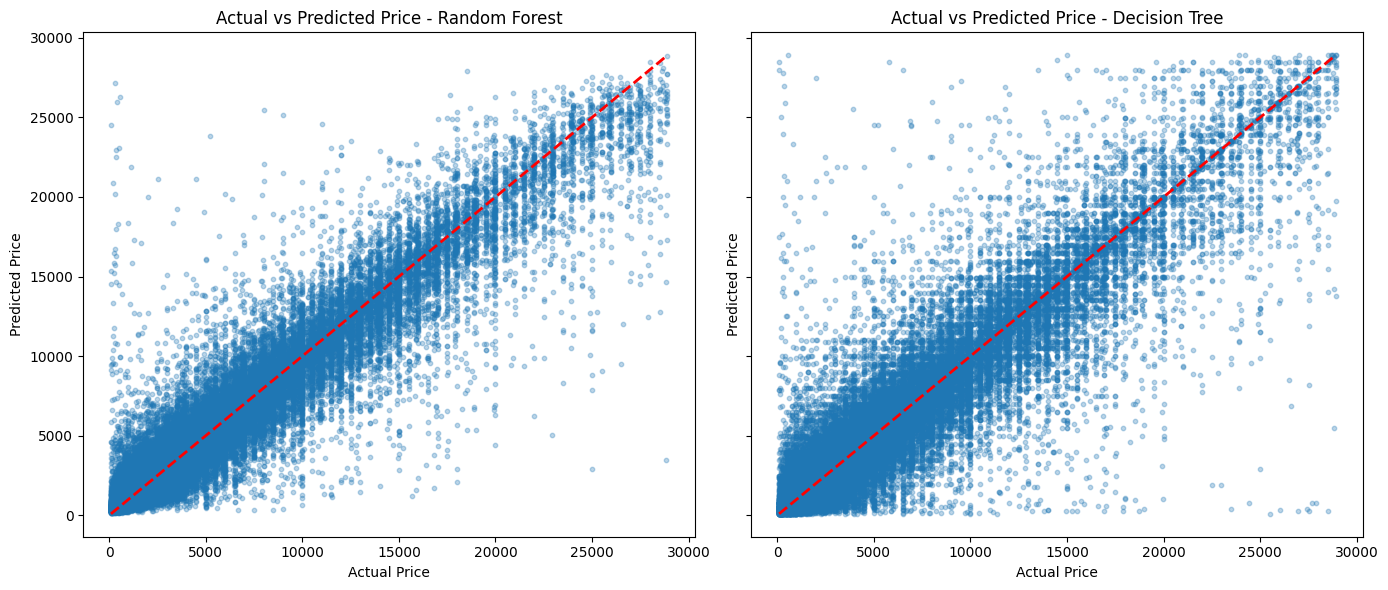

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

plot_data = [
    (axes[0], rf_test_pred, "Random Forest"),
    (axes[1], dt_test_pred, "Decision Tree"),
]

min_price = y_test.min()
max_price = y_test.max()

for ax, prediction, title in plot_data:
    ax.scatter(y_test, prediction, alpha=0.3, s=10)
    ax.plot([min_price, max_price], [min_price, max_price], "r--", lw=2)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"Actual vs Predicted Price - {title}")

plt.tight_layout()
plt.show()

#### Interpretasi Output

Scatter plot menunjukkan seberapa dekat prediksi model dengan harga aktual. Titik yang dekat dengan garis merah berarti prediksi semakin baik. Sebaran titik yang cukup lebar menunjukkan masih ada error prediksi, terutama pada mobil dengan harga tinggi.

## 6. Kesimpulan

Berdasarkan hasil evaluasi, Random Forest Regressor dipilih sebagai model terbaik karena memiliki nilai MAE dan RMSE lebih rendah serta R2 lebih tinggi dibanding Decision Tree Regressor pada data test. Model ini mampu memprediksi harga mobil bekas dengan performa yang cukup baik, meskipun masih terdapat sebaran error terutama pada mobil dengan harga yang lebih tinggi.